# 10b. Curriculum-Aware LLM Analysis: Students 14475 & 14476
This notebook runs the Curriculum-Aware LLM analysis on students 14475 and 14476. 

In [6]:
import os
import sys
import json
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict

# Add project root to path for imports
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from utils.dataset import load_joined_datasets, get_best_attempts, load_topics_json, load_problem_descriptions
from lib.mental_model import calculate_student_profile, get_weak_skills, build_mental_model_payload, load_skill_map, build_prerequisite_graph
from lib.prompts import build_curriculum_aware_prompt
from lib.llm_batch_analyzer import format_submissions, clean_json_response
from google import genai
from google.genai import types

# Constants
MODEL_ID = "gemini-2.0-flash" 
SLEEP_SECONDS = 1.0
STUDENT_IDS = [14475, 14476]

VIZ_FOLDER = "results/visualizations/"
OUTPUT_DIR = "results/human_validation/"

# Ensure output directories exist
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(VIZ_FOLDER, exist_ok=True)

# EXACT KC Vocabulary
EXACT_KC_TAGS = [
    'If/Else', 'NestedIf', 'While', 'For', 'NestedFor',
    'Math+-*/', 'Math%', 'LogicAndNotOr', 'LogicCompareNum', 'LogicBoolean',
    'StringFormat', 'StringConcat', 'StringIndex', 'StringLen',
    'StringEqual', 'CharEqual', 'ArrayIndex', 'DefFunction'
]
VALID_KC_SET = set(EXACT_KC_TAGS)

# Initialize LLM Client
client = genai.Client(api_key=os.environ.get("GEMINI_API_KEY"))

def extract_kc_tags(output_obj) -> List[str]:
    if not isinstance(output_obj, dict):
        return []

    valid_tags = set()
    analysis_list = output_obj.get("student_analysis", [])
    if not isinstance(analysis_list, list):
        analysis_list = []

    for analysis in analysis_list:
        if not isinstance(analysis, dict): continue
        for gap in analysis.get("knowledge_gaps", []):
            tag = ""
            if isinstance(gap, dict):
                tag = gap.get("missing_concept", "")
            elif isinstance(gap, str):
                tag = gap
            tag = tag.strip()
            if tag in VALID_KC_SET:
                valid_tags.add(tag)

        for pred in analysis.get("future_predictions", []):
            tag = ""
            if isinstance(pred, dict):
                tag = pred.get("at_risk_topic", "")
            elif isinstance(pred, str):
                tag = pred
            tag = tag.strip()
            if tag in VALID_KC_SET:
                valid_tags.add(tag)

    for key in ["knowledge_gaps", "future_predictions"]:
        val = output_obj.get(key, [])
        if isinstance(val, list):
            for item in val:
                if isinstance(item, str):
                    tag = item.strip()
                    if tag in VALID_KC_SET:
                        valid_tags.add(tag)

    return sorted(list(valid_tags))

def add_mental_model_context(base_prompt: str, mental_model_payload: dict) -> str:
    context = json.dumps(mental_model_payload, indent=2)
    return (
        base_prompt
        + "\n\nAdditional Student Mental Model Context:\n"
        + context
        + "\n\nUse this context to better judge likely misconceptions and future risks."
    )

In [7]:
# Load dataset and skill maps once
full_dataset = load_joined_datasets("dataset/CodeWorkout/")
best_attempts = get_best_attempts(full_dataset)

skill_map, all_skills = load_skill_map("dataset/CodeWorkout/Problem_Prompts/problem_prompts.csv")
prereq_graph = build_prerequisite_graph()
topics = load_topics_json()
problems_desc = load_problem_descriptions()

print(f"Loaded datasets, {len(all_skills)} KCs, and dependency graph.")

Main table: 201,570 rows
CodeState table: 69,627 rows
Subject table: 381 rows
Joined dataset: 191,584 rows
Best attempts: 15,375 rows (372 students, 50 problems)
Loaded datasets, 18 KCs, and dependency graph.



Processing Student 14475

Loaded 50 attempted problems.
Starting batch analysis for 50 attempts...
Analyzing Problem 1 (Attempts score: 100.00%)...
  > Identified gaps: None
Analyzing Problem 3 (Attempts score: 100.00%)...
  > Identified gaps: None
Analyzing Problem 5 (Attempts score: 100.00%)...
  > Identified gaps: None
Analyzing Problem 12 (Attempts score: 100.00%)...
  > Identified gaps: None
Analyzing Problem 13 (Attempts score: 100.00%)...
  > Identified gaps: None
Analyzing Problem 17 (Attempts score: 100.00%)...
  > Identified gaps: None
Analyzing Problem 20 (Attempts score: 100.00%)...
  > Identified gaps: None
Analyzing Problem 21 (Attempts score: 100.00%)...
  > Identified gaps: None
Analyzing Problem 22 (Attempts score: 100.00%)...
  > Identified gaps: None
Analyzing Problem 24 (Attempts score: 100.00%)...
  > Identified gaps: None
Analyzing Problem 25 (Attempts score: 100.00%)...
  > Identified gaps: None
Analyzing Problem 28 (Attempts score: 100.00%)...
  > Identified ga

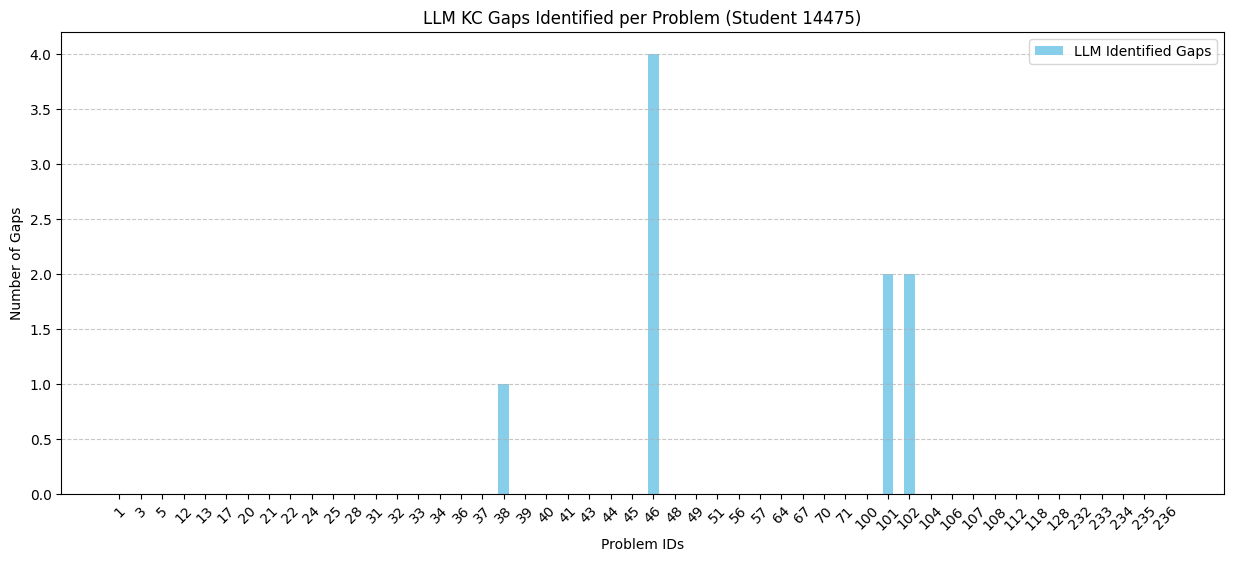


Processing Student 14476

Loaded 50 attempted problems.
Starting batch analysis for 50 attempts...
Analyzing Problem 1 (Attempts score: 100.00%)...
  > Identified gaps: None
Analyzing Problem 3 (Attempts score: 75.00%)...
  > Identified gaps: LogicAndNotOr, LogicCompareNum, NestedIf
Analyzing Problem 5 (Attempts score: 62.50%)...
  > Identified gaps: If/Else, LogicAndNotOr, LogicCompareNum
Analyzing Problem 12 (Attempts score: 85.00%)...
  > Identified gaps: If/Else, LogicAndNotOr, LogicBoolean
Analyzing Problem 13 (Attempts score: 82.61%)...
  > Identified gaps: If/Else, LogicAndNotOr, LogicBoolean
Analyzing Problem 17 (Attempts score: 100.00%)...
  > Identified gaps: None
Analyzing Problem 20 (Attempts score: 100.00%)...
  > Identified gaps: None
Analyzing Problem 21 (Attempts score: 100.00%)...
  > Identified gaps: None
Analyzing Problem 22 (Attempts score: 100.00%)...
  > Identified gaps: None
Analyzing Problem 24 (Attempts score: 100.00%)...
  > Identified gaps: None
Analyzing Pr

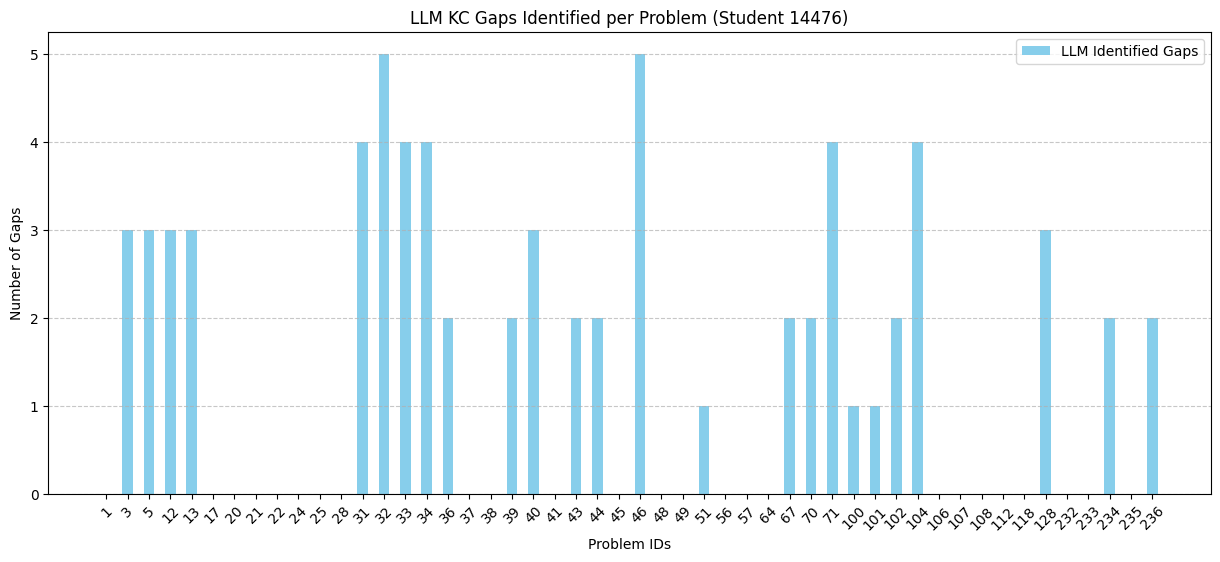


Done processing all students!


In [8]:
for student_id in STUDENT_IDS:
    print(f"\n{'='*50}")
    print(f"Processing Student {student_id}")
    print(f"{'='*50}\n")
    
    # 1. Subject specific attempts
    student_best_attempts = best_attempts[best_attempts['SubjectID'] == student_id]
    student_best_attempts = student_best_attempts.sort_values('ProblemID')
    
    if len(student_best_attempts) == 0:
        print(f"No attempts found for student {student_id}. Skipping.")
        continue
        
    print(f"Loaded {len(student_best_attempts)} attempted problems.")
    
    # 2. Build student profile & mental model context
    student_profile = calculate_student_profile(student_id, student_best_attempts, skill_map, all_skills)
    weak_skill_pairs = get_weak_skills(student_profile, threshold=0.6) 
    
    mental_model_payload = build_mental_model_payload(
        student_id, student_profile, weak_skill_pairs, prereq_graph
    )
    
    # 3. Create enriched prompt
    all_problem_ids = student_best_attempts['ProblemID'].astype(int).tolist()
    baseline_system_prompt = build_curriculum_aware_prompt(
        topics=topics,
        problems=problems_desc,
        focus_problem_ids=all_problem_ids
    )
    enriched_system_instruction = add_mental_model_context(baseline_system_prompt, mental_model_payload)
    
    # 4. LLM processing loop
    llm_results = {}
    total_attempts = len(student_best_attempts)
    print(f"Starting batch analysis for {total_attempts} attempts...")
    
    for index, row in student_best_attempts.iterrows():
        problem_id = str(row['ProblemID'])
        score = row['Score']
        
        print(f"Analyzing Problem {problem_id} (Attempts score: {score * 100:.2f}%)...")
        formatted_input = format_submissions([row.to_dict()])
        
        try:
            response = client.models.generate_content(
                model=MODEL_ID,
                contents=formatted_input,
                config=types.GenerateContentConfig(
                    system_instruction=enriched_system_instruction,
                    temperature=0.3,
                    response_mime_type='application/json',
                ),
            )
            raw_text = response.text if response and response.text else '{}'
            cleaned_response = clean_json_response(raw_text)
            parsed_response = json.loads(cleaned_response)
            gaps = extract_kc_tags(parsed_response)
            
            llm_results[problem_id] = {
                "gaps": gaps,
                "score": score,
                "raw_response": raw_text
            }
            print(f"  > Identified gaps: {', '.join(gaps) if gaps else 'None'}")
            
        except Exception as e:
            print(f"Error on problem {problem_id}: {e}")
            llm_results[problem_id] = {"gaps": [], "error": str(e)}

        time.sleep(SLEEP_SECONDS)
        
    # 5. Save results
    final_json = {
        "rater": "LLM_Gemini_Enriched",
        "studentId": str(student_id),
        "exportDate": time.strftime("%Y-%m-%dT%H:%M:%S.000Z"),
        "annotations": {pid: {"gaps": data["gaps"]} for pid, data in llm_results.items()}
    }
    
    output_path = os.path.join(OUTPUT_DIR, f"llm_annotations_{student_id}.json")
    with open(output_path, 'w') as f:
        json.dump(final_json, f, indent=2)
    print(f"\nSaved LLM results to: {output_path}")
    
    # 6. Plot problem-by-problem KC tags (no human labels)
    pids = list(llm_results.keys())
    problem_labels = [str(pid) for pid in pids]
    llm_counts = [len(llm_results[pid]['gaps']) for pid in pids]
    
    plt.figure(figsize=(15, 6))
    x = np.arange(len(pids))
    
    plt.bar(x, llm_counts, width=0.5, color='skyblue', label='LLM Identified Gaps')
    plt.xlabel('Problem IDs')
    plt.ylabel('Number of Gaps')
    plt.title(f'LLM KC Gaps Identified per Problem (Student {student_id})')
    plt.xticks(x, problem_labels, rotation=45)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plot_path = os.path.join(VIZ_FOLDER, f"student_{student_id}_llm_gaps.png")
    plt.savefig(plot_path)
    plt.show()

print("\nDone processing all students!")